In [15]:
#=======================
# não altere essa célula
#=======================

import pickle
from torch.utils.data import DataLoader
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math

with open('data.pkl', 'rb') as handle:
    dataset = pickle.load(handle)

training_data = list(zip(dataset['x'].astype(np.float32),dataset['y']))
test_data = list(zip(dataset['x_test'].astype(np.float32),dataset['y_test']))

train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_data, batch_size=100, shuffle=False)

O dataset representa uma tarefa de classificação com 10 classes e é composto por um input sequencial com 40 float features e um output inteiro contendo o índice da classe de cada amostra (i.e. de 0 a 9).

In [3]:
for X, y in train_dataloader:
    print(f"Shape of X [N, L]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, L]: torch.Size([32, 40])
Shape of y: torch.Size([32]) torch.int64


**DATASET:**
Ao ler o livro *Understanding Deep Learning*, percebeu-se que o dataset em questão é o MNIST-1D, e temos as seguintes informações sobre o mesmo:

- **Formato de cada amostra:**
  - **40** - Tamanho da entrada
  - **32** - Tamanho do batch
  - **4000** - Número de amostras

In [4]:
import torch
from torch import nn

# Get cpu, gpu or mps device for training.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


Altere as classes abaixo implementando os seguintes modelos:

1. modelo de classificação linear
2. mlp com no máximo 20k parâmetros (contando pesos e biases)
3. rede convolucional estilo LeNet
4. rede convolucional estilo VGG
5. rede convolucional estilo ResNet

(extra)
6. rede recorrente
7. rede estilo ViT

# IMPLEMENTAÇÕES

In [13]:
"""
Nessa célula iremos realizar as implementações propostas, Optamos por definir
a rede, não deixando-a parametrizável a primeiro momento. Em uma célula
posterior, serão implementadas versões da VGG e RESNET que possuem camadas
parâmetrizáveis.
"""

class LinearNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.pesos = nn.Linear(40, 10, bias=True)

    def forward(self, x):
        x = self.pesos(x)  # Aplicar os pesos e bias, sem função de ativação
        return x


class MLPNet(nn.Module):
    """
    Nessa rede temos ao total 18.760 parâmetros, para obter esse número
    basta contar a quantidade de neurônios multiplicado pela quantidade de
    entradas + 1 (bias), isso para cada camada da rede. Asim, temos:
        200 * 41 = 8.200
        50 * 201 = 10.050
        10 * 51 = 510

    Somando tudo temos os 18.760 parâmetros descritos, incluindo pesos
    e bias.
    """

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(40, 200, bias = True)
        self.fc2 = nn.Linear(200, 50, bias = True)
        self.fc3 = nn.Linear(50, 10, bias = True)

        """
        fc é uma abraviação para fully conected (totalmente conectada), que é
        o conceito de uma mlp, onde todas as entradas estão conectadas atráves
        de um peso a cada neurônio, e cada saída de uma camada pode ser entrada
        para uma proxima.
        """

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x



class LeNet(nn.Module):
    """
    Em um alto nível, o LeNet (LeNet-5) consiste em duas partes: um
    codificador convolucional consistindo de duas camadas convolucionais; e um
    bloco denso consistindo de três camadas totalmente conectadas. Além disso
    contamos com as camadas de pooling e funções de ativação, no paper original
    é utilizado sigmoid/tangente hiperbólica, nessa implementação usaremos a
    relu, como também, usaremos a conv1d, pois se tratam de dados não
    bidimensionais . Um ponto de extrema atenção, é que ReLUs e max-pooling
    ainda não haviam sido descobertos na idealização da LeNet, mas serão
    utilizadas, pois geram um bom aumento de desempenho, juntamente com a
    softmax presente na função de perca, diferente do decodificador gaussiano,
    inicialmente proposto. Além disso, a arquitetura segue o seguinte modelo:

        Primeira Camada Convolucional: a primeira camada convolucional possui 6
        filtros 1x5 com stride 1 e padding 2, essa escolha foi feita para
        manter o resultado da convolução com o mesmo tamanho de sua entrada
        (40). Assim, se assemelhando mais a resnet tradicional que após a
        primeira convolução, gera um feature map de 6 por 28x28 (mesmo tamanho
        da entrada).

        Primeira Camada de pooling: a primeira camada de pooling é um
        max_pooling 1x2 com stride 2, assim reduzindo o tamanho de x pela
        metade (20), assim como na publicação da resnet.

        Segunda Camada Convolucional: a segunda camada convolucional implementa
        16 filtros 1x5, com stride 1 e padding 0, assim reduzindo o tamanho de
        x para 16x16, onde temos 16 mapas de taamnho 16 cada. Redução
        proporcional a resnet original

        Segunda Camada de pooling: a segunda camada de pooling é um max_pooling
        1x2 com stride 2, reduzindo x para 16x8, 16 mapas com 8 de tamanho cada,
        tendo papel semelhante a da implementação original que reduz o
        resultado da segunda camada convolucional pela metade.

        A partir dai as features sofrem um flatten (achatamento) e servirão de
        entrada para uma totalmente conectada (mlp), essa totalmente conectada
        tem :

            Primeira camada mlp: 50 neurônios com 16*8 pesos cada, quantidade
            de "features" que temos após aplicar a segunda camada de pooling.

            Segunda camada mlp: 30 neurônios com 50 pesos cada, quantidade de
            neurônios da camada anterior.

            Terceira camada mlp: 10 neurônios (quantidade de classes) com 30
            pesos cada, quantidade de neurônios da camada anterior.

            O número de neurônios da totalmente conectada foi reduzido, visto
            que na original haviam 120, 84 e 10 neurônios por cada, isso foi
            feito a fim de gerar menos parâmetros que a mlp anteriormente
            implementada.


    Calculo dos parâmetros:
    Para os kernels, temos:
    in_channels * kernel_size * out_channels + out_channles(bias) por camada,
    assim, temos:

          conv1: 1x6x5 + 6 = 36 parâmetros
          conv2: 6x5x16 + 16 = 496 parâmetros

          fc1: 50 x (16*8 + 1) = 6450 parâmetros
          fc2: 30 x 51 = 1530 parâmetros
          fc3: 10 x 31 = 310 parâmetros

      Desse modo, nossa lenet possui 8.822 parâmetros, contabilizando
      pesos e bias, sendo mais de 2 vezes menor que a mlp implementada
    """

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=6,
                               kernel_size=5, stride=1,
                               padding=2, padding_mode='zeros')

        self.conv2 = nn.Conv1d(in_channels=6, out_channels=16,
                               kernel_size=5, stride=1, padding=0)

        self.fc1 = nn.Linear(16 * 8, 50, bias = True)
        self.fc2 = nn.Linear(50, 30, bias = True)
        self.fc3 = nn.Linear(30, 10, bias = True)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)

        x = F.relu(self.conv1(x))
        x = F.max_pool1d(x, kernel_size=2, stride=2)

        x = F.relu(self.conv2(x))
        x = F.max_pool1d(x, kernel_size=2, stride=2)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


class VGGNet(nn.Module):
    """
    A VGG segue a ideia de usar muitas camadas convolucionais com filtros
    pequenos, aumentando a profundidade da rede e surge também com a ideia da
    utilização de "blocos", onde o blocco de construção básico das CNNs é uma
    sequência do seguinte:

    uma camada convolucional com padding para manter a resolução,
    uma função de ativação, como uma ReLU,
    uma camada de pooling como max-pooling para reduzir a resolução.

    Um dos problemas com essa abordagem é que a resolução espacial diminui muito
    rapidamente, isso impõe um limite de camadas convolucionais na rede. Por
    exemplo, no caso do ImageNet, seria impossível ter mais de 8 camadas
    convolucionais dessa forma.

    Assim como a AlexNet (sua antecessora) e a LeNet, a VGG pode ser
    particionada em duas partes: a primeira consistindo de camadas
    convolucionais e de pooling e a segunda consistindo de camadas totalmente
    conectadas. Em um alto nível, podemos enxergar como se as camadas
    convolucionais tivessem o papel de entregar as melhores features para
    aquelas tarefas (features essas que serão aprendidas pelo backpropagation)
    e a totalmente conectada o papel de classificar baseado nessas features
    entregues, esse paralelo serve também para a Lenet.

    A principal diferença, além do ganho de profundidade da rede está em que as
    camadas convolucionais são agrupadas em transformações não lineares que
    deixam a dimensionalidade inalterada, seguidas por uma etapa de redução de
    resolução.

    Para essa implementação serão usados 3 blocos, onde serão combinadas convs
    e funções de ativação, e ao final de cada bloco, teremos uma max_pooling com
    kernel 1x2 e stride 2, reduzindo sempre pela metade o tamanho da entrada.
    Detalhe é que as convs sempre possuem o mesmo kernel_size e geram
    mapas com a mesma dimensão de entrada, a redução da resolução fica por conta
    da max_pooling ao final de cada bloco.

    Para a totalmente conectada serão usados 3 camadas, com 4096, 4096 e 10
    neurônios respectivamente. Como novidade, há a utilização do dropout a fim
    de trazer uma regularização a rede, uma visão interessante sobre o mesmo é
    que pode ser visto como um "ensemble" de redes neurais.



    Calculo dos parâmetros:
    Para os kernels, temos:
    in_channels * kernel_size * out_channels + out_channles(bias) por camada,
    assim, temos:

        conv1: 1x64x3 + 64 = 192 parâmetros
        conv2: 64x64x3 + 64 = 12.288 parâmetros
        conv3: 64x128x3 + 128 = 24.576 parâmetros
        conv4: 128x128x3 + 128 = 49.152 parâmetros
        conv5: 128x256x3 + 256 = 98.304 parâmetros
        conv6: 256x256x3 + 256 = 196.608 parâmetros
        conv7: 256x256x3 + 256 = 196.608 parâmetros


        fc1: 4096 x (256*5 + 1) = 5.431.296 parâmetros
        fc2: 4096 x 4097 = 16.781.312 parâmetros
        fc3: 10 x 4097 = 40.970 parâmetros

    Desse modo, nossa VGG com 3 blocos possui 22.831.306 parâmetros,
    contabilizando pesos e bias, sendo absurdamente maior que as demais redes
    implementadas, muito graças ao tamanho de sua totalmente conectada.



    A vgg implementada segue uma convnet do tipo C, mas sem o quarto bloco vgg,
    essa escolha de "capar" o último bloco se da pela quantidade de parâmetros
    de entrada para a mlp, visto que baixar mais ainda a resolução de entrada
    resultaria em uma resolução de 2 ou 3 em 512 mapas, nos nossos testes essa
    rede desempenhou pior, além de trazer esse fator pode contribuir com vanish
    gradient.
    """

    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            #Primeiro bloco VGG
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),

            # Segundo bloco VGG
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),

            #Terceiro bloco VGG
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
        )

        """
        No último bloco VGG, temos como saída 256 mapas de features, como são
        3 blocos ao longo da rede, onde cada bloco reduz a resolução em 2x
        temos como entrada no primeiro bloco um tamanho de 40, no segundo um
        tamanho de 20, no terceiro um tamanho de 10, e na primeira camada da
        totalmente conectada temos 5, isso para cada mapa de features, o que
        resulta na entrada de tamanho 256x5
        """
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 5, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


class ResNet(nn.Module):
    """
    A medida que a rede fica mais profunda, ela é capaz de aproximar um conjunto
    maior de funções, e em teoria ficar mais "poderosa", contudo, foi observado
    que isso não era necessáriamente verdade, uma das principais hípoteses é
    de que para uma rede altamente profunda, mudar um pouco a entrada pode
    gerar um gradiente completamente diferente. Isso não costuma acontecer nas
    redes mais rasas, visto que os gradientes são mais correlacionados, mas
    essa correlação cai rapidamente para zero para redes profundas, fenômeno
    conhecido como shattered gradients. A maneira de se resolver isso nas
    conexões residuais é transformando a rede original em um conjunto de redes
    menores cujas saídas são somadas para calcular o resultado.

    Além disso, está incluso a camada de batch normalization, que mesmo com
    princípios falhos do artigo, busca resolver as diferenças de magnitude
    entre camadas, por exemplo, se uma camada tiver ativações variáveis que são
    100 vezes maiores que as de outra camada, isso pode necessitar de ajustes
    compensatórios nas taxas de aprendizado. Um fato interessante é que a batch
    norm mitiga a necessidade de uma inicialização correta dos pesos.

    Ainda assim, a implementação tomou como base a implementação anterior da
    vgg, mas adicionando um novo "bloco". Nas arquiteturas ResNet, incluindo a
    nossa adaptação, as conexões residuais funcionam adicionando a saída de um
    bloco de camadas convolucionais à sua entrada, efetivamente permitindo que o
    bloco aprenda uma função de "perturbação" da identidade ao invés de
    aprender diretamente a transformação desejada. Isso ajuda a mitigar o
    problema dos shattered gradients
    Em nossa rede, cada bloco residual consiste em duas camadas convolucionais
    seguidas por uma batch_norm e ativação ReLU. A saída destas duas camadas é
    então somada com a entrada do bloco através de um atalho, que é ajustado
    para alinhar as dimensões quando necessário usando uma convolução 1x1.
    """

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=2, stride=2)

        self.layer1_1 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn1_1 = nn.BatchNorm1d(64)
        self.layer1_2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.bn1_2 = nn.BatchNorm1d(64)

        self.layer2_1 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn2_1 = nn.BatchNorm1d(128)
        self.layer2_2 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn2_2 = nn.BatchNorm1d(128)

        self.layer3_1 = nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn3_1 = nn.BatchNorm1d(256)
        self.layer3_2 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn3_2 = nn.BatchNorm1d(256)

        self.layer4_1 = nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1)
        self.bn4_1 = nn.BatchNorm1d(512)
        self.layer4_2 = nn.Conv1d(512, 512, kernel_size=3, padding=1)
        self.bn4_2 = nn.BatchNorm1d(512)

        self.fc_layers = nn.Sequential(
            nn.Linear(512 * 3, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

        self.shortcut1 = nn.Sequential()
        self.shortcut2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=1, stride=2),
            nn.BatchNorm1d(128)
        )
        self.shortcut3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=1, stride=2),
            nn.BatchNorm1d(256)
        )
        self.shortcut4 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=1, stride=2),
            nn.BatchNorm1d(512)
        )

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)  # Ajuste o input para 1D
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self._residual_block(x, self.layer1_1, self.bn1_1,
                                 self.layer1_2, self.bn1_2, self.shortcut1)

        x = self._residual_block(x, self.layer2_1, self.bn2_1,
                                 self.layer2_2, self.bn2_2, self.shortcut2)

        x = self._residual_block(x, self.layer3_1, self.bn3_1,
                                 self.layer3_2, self.bn3_2, self.shortcut3)

        x = self._residual_block(x, self.layer4_1, self.bn4_1,
                                 self.layer4_2, self.bn4_2, self.shortcut4)

        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

    def _residual_block(self, x, conv1, bn1, conv2, bn2, shortcut):
        residual = shortcut(x)
        x = self.relu(bn1(conv1(x)))
        x = bn2(conv2(x))
        x += residual
        x = self.relu(x)
        return x


class RecurrentNet(nn.Module):
    """
    Em uma Rede Neural Recorrente (RNN), os neurônios têm conexões direcionadas
    para si mesmos e para outras unidades, criando um ciclo de realimentação.
    Esse ciclo permite que a RNN mantenha uma "memória" de informações
    anteriores, sendo útil para dados sequenciais. Na nossa implementação, temos
    uma estrutura básica de uma RNN com os seguintes componentes:

    Tamanho do estado escondido: 128 neurônios na camada escondida.

    Linear i2h: transforma a entrada de 40 dimensões para o tamanho do estado
    escondido (128).

    Linear h2h: transforma o estado escondido anterior de volta para o tamanho
    do estado escondido, permitindo a passagem de informações através do tempo.

    Linear h2o: transforma o estado escondido para a dimensão da saída desejada
    (10 classes).

    Softmax: função de ativação na saída para calcular a probabilidade das
    classes.

    """
    def __init__(self):
        super().__init__()
        self.hidden_size = 128
        self.i2h = nn.Linear(40, 128)
        self.h2h = nn.Linear(128, 128)
        self.h2o = nn.Linear(128, 10)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input):
        batch_size = input.size(0)
        hidden = self.initHidden(batch_size)
        output, hidden = self.step(input, hidden)
        return output

    def step(self, input, hidden):
        hidden = torch.tanh(self.i2h(input) + self.h2h(hidden))
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self, batch_size):
        return torch.zeros(batch_size, self.hidden_size).to(device)


class ViTNet(nn.Module):
    """
    Este modelo é uma versão simplificada de um Transformer. A grande sacada
    aqui é o uso de autoatenção, uma técnica que permite que cada parte da
    imagem "olhe" e dê importância a todas as outras partes, ajudando a decidir
    que número está sendo mostrado.

    O modelo segue a seguinte arquitetura:

    - Transformação inicial: Primeiro, transformamos os dados de entrada, que
    têm 40 pontos cada, em uma representação mais densa de 64 dimensões
    (embeedings). Dentro do que foi estudado, é possível entender que essa parte
    tem um papel de encoder dentro da arquitetura, e pode ser utilizada de
    maneira isolada para outras tarefas que necessitem de uma representação de
    imagem

    - Adicionando posição: Como estamos lidando com sequências (neste caso, uma
    sequência de pontos numa imagem 1D), é importante saber a ordem dos dados.
    Para isso, adicionamos informações de posição a essas transformações
    iniciais, para que o modelo não perca a noção de onde cada ponto está na
    imagem. Isso é feito por que o mecanismo de atenção é puramente
    multiplicações entre entradas que passarão em uma softmax, assim não
    preservando informação de posição, se não adicionarmos o positional, uma
    imagem que possua os mesmos pixels do 1 mas que não esteja organizada como o
    1 será representada literalmente igual para o modelo, o que não queremos

    - **Olhando os dados com atenção**: Usamos autoatenção para fazer cada ponto
    da imagem verificar todos os outros pontos e decidir quais são importantes.
    Isso é feito criando três cópias de nossos dados transformados (chamadas
    de query, key e value):
        - Query: Representa o ponto que estamos tentando entender.
        - Key: Representa todos os pontos, usados para comparar com a query.
        - Value: Também representa todos os pontos, mas é usado para compilar a
        resposta final com base em quanto cada ponto é relevante.
      Comparamos as queries com as keys para decidir quais partes da imagem são
      importantes para entender o ponto atual, e usamos essa informação para
      ponderar nossos values. Isso é feito com uma fórmula matemática que
      basicamente mede quão similares são a query e cada key, usando um produto
      interno, e então usa isso para misturar os values de uma forma que destaca
       os pontos mais importantes.

    - Classificador: Depois de passar pela atenção, passamos as informações
    através de uma camada que normaliza (ajusta) os dados para evitar que os
    valores se descontrolem, e depois por um pequeno conjunto de camadas
    totalmente conectadas para gerar a classificação.
    """
    def __init__(self, input_dim=40, num_classes=10,
                 num_heads=2, d_model=64, mlp_dim=128):
        super(ViTNet, self).__init__()

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        assert d_model % num_heads == 0

        self.embed = nn.Linear(input_dim, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, d_model, input_dim))

        self.query = nn.Linear(d_model, d_model, bias=False)
        self.key = nn.Linear(d_model, d_model, bias=False)
        self.value = nn.Linear(d_model, d_model, bias=False)

        self.norm = nn.LayerNorm(d_model)
        self.fc1 = nn.Linear(d_model, mlp_dim)
        self.fc2 = nn.Linear(mlp_dim, num_classes)

    def forward(self, x):
        x = self.embed(x)

        pos_embed = self.pos_embed.repeat(x.size(0), 1, 1)
        x = x.unsqueeze(2) + pos_embed
        x = x.permute(0, 2, 1)

        query = self.query(x).view(x.size(0),
                                   x.size(1),
                                   self.num_heads,
                                   self.head_dim).transpose(1, 2)

        key = self.key(x).view(x.size(0),
                               x.size(1),
                               self.num_heads,
                               self.head_dim).transpose(1, 2)

        value = self.value(x).view(x.size(0),
                                   x.size(1),
                                   self.num_heads,
                                   self.head_dim).transpose(1, 2)

        scores = torch.matmul(query, key.transpose(-2, -1)) \
                  / math.sqrt(self.head_dim)


        attention = torch.softmax(scores, dim=-1)
        x = torch.matmul(attention, value) \
                 .transpose(1, 2) \
                 .contiguous() \
                 .view(x.size(0), x.size(1), self.d_model)

        x = self.norm(x.mean(dim=1))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

**Detalhes Específicos de Cada Implementação**
As explicações também estão presentes e mais detalhadas nos códigos:

- **Linear**:
  A rede linear não possui função de ativação (meio-óbvio) e é composta por uma linear com 10 neurônios (um para cada classe) e 40 pesos (tamanho da entrada) para cada neurônio.

- **MLP**:
  A MLP (totalmente conectada) foi implementada com 3 camadas, utilizando a função de ativação relu para cada uma. Para a última camada, não foi implementada a função softmax, pois a mesma já está embutida na função de custo (entropia cruzada). No total, temos 18.760 parâmetros, contabilizando pesos e bias.

- **LeNet**:
  Em um alto nível, o LeNet (LeNet-5) consiste em duas partes: um codificador convolucional consistindo de duas camadas convolucionais; e um bloco denso consistindo de três camadas totalmente conectadas. As seguintes mudanças foram feitas em relação ao paper original:
    - Implementamos a conv1d, pois temos dados não bidimensionais.
    - Utilizamos maxpooling, diferente da avg proposta no paper.
    - Utilizamos Relu, diferente da sigmoid proposta no paper.
    Após passar pelas convs, o x sofre um flatten e passamos ele para o classificador (mlp), resultando em uma rede com 8.822 parâmetros, mais de 2 vezes menos que a MLP.

- **VGG**:
  A VGG segue a ideia de usar muitas camadas convolucionais com filtros pequenos, aumentando a profundidade da rede e também a utilização de "blocos". Foram implementados 3 blocos, arquitetura semelhante à ConvNet do tipo C proposta no paper, mas sem o quarto bloco VGG, visto que nos testes, aumentar demais o número de camadas começava a causar problemas. A rede final ficou com o total de 22.831.306 parâmetros.

- **ResNet**:
  A ResNet vem para resolver o problema onde aumentar demais a profundidade da rede causava uma perda de desempenho, onde a principal teoria do por quê está por trás dos shattered gradients. Com isso, a ResNet implementa a ideia de conexões residuais que funcionam adicionando a saída de um bloco de camadas convolucionais à sua entrada, efetivamente permitindo que o bloco aprenda uma função de "perturbação" da identidade ao invés de aprender diretamente a transformação desejada. Além disso, é trazida a ideia de camadas de batch_norm.

- **RecurrentNet**:
  Na RNN os neurônios têm conexões direcionadas para si mesmos e para outras unidades, criando um ciclo de realimentação. implementamos com 128 neurônios na camada escondida. Uma boa propriedade das RNN's é que podemos utilizar quantos dados quisermos na inferência, isso por que a rede re-aplicada a sequência é a mesma, somada ao h dos itens anteriores das sequências.
  
- **Vit**:
    Utilizamos o mecanismo de autoatenção para permitir que cada ponto de entrada avalie a importância de todos os outros.(mais detalhado no código)

  **Arquitetura**:
  - **Transformação Inicial**: Converte os dados de entrada em representações densas de 64 dimensões, funcionando como um encoder.
  - **Posição**: Adiciona informações posicionais que são cruciais, pois a atenção não preserva a ordem dos dados por si só.
  - **Autoatenção**: Emprega queries, keys e values para determinar os pontos importantes da entrada, utilizando produto interno e softmax para destacar os mais relevantes.
  - **Classificador**: Após a atenção, os dados são normalizados e processados por camadas totalmente conectadas para a classificação final.
  

# TESTE

In [9]:
# altere o modelo
model = VGGNet().to(device)
print(model)

# altere a função de custo e o otimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

VGGNet(
  (conv_layers): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU(inplace=True)
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU(inplace=True)
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (6): ReLU(inplace=True)
    (7): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (8): ReLU(inplace=True)
    (9): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): ReLU(inplace=True)
    (12): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (13): ReLU(inplace=True)
    (14): Conv1d(256, 256, kernel_size=(3,), stride=(1,), padding=(1,))
    (15): ReLU(inplace=True)
    (16): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers)

In [10]:
#=======================
# não altere essa célula
#=======================

def train(dataloader, model, loss_fn, optimizer):
    train_loss = []
    train_acc = []

    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += [loss.item()]

        correct = (pred.argmax(1) == y).type(torch.float).mean().item()
        train_acc += [100*correct]

    return train_loss, train_acc

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    test_acc = 100*correct/size

    return test_loss, test_acc

In [11]:
epochs = 50

In [ ]:
#=======================
# não altere essa célula
#=======================

from tqdm import trange

train_loss_hist = []
train_acc_hist = []

test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
test_loss_hist = [test_loss_0]
test_acc_hist = [test_acc_0]

for t in trange(epochs):
    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    train_loss_hist += train_loss
    train_acc_hist += train_acc

    test_loss, test_acc = test(test_dataloader, model, loss_fn)
    test_loss_hist += [test_loss]
    test_acc_hist += [test_acc]

train_loss_hist = np.array(train_loss_hist)
test_loss_hist = np.array(test_loss_hist)
train_acc_hist = np.array(train_acc_hist)
test_acc_hist = np.array(test_acc_hist)

In [ ]:
print(f"LOSS FINAL TREINO: {train_loss_hist[-1]}")
print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
print()
print(f"ACC FINAL TREINO: {train_acc_hist[-1]}")
print(f'ACC FINAL TESTE: {test_acc_hist[-1]}')

LOSS FINAL TREINO: 0.0005821140948683023
LOSS FINAL TESTE: 0.04547279169782996

ACC FINAL TREINO: 100.0
ACC FINAL TESTE: 98.4


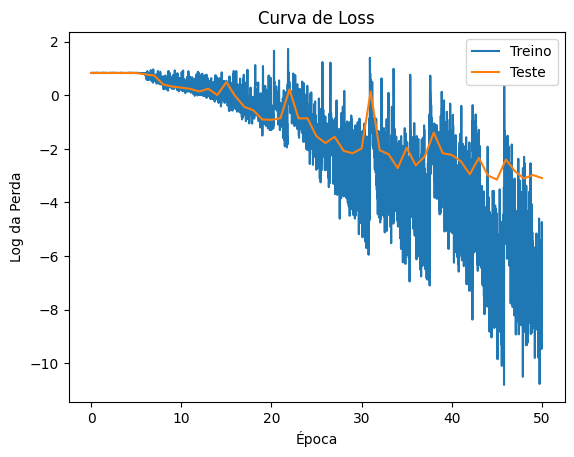

In [ ]:
x_axis = np.linspace(0, epochs, len(train_loss_hist))
plt.plot(x_axis, np.log(train_loss_hist), label='Treino')
plt.plot(np.log(test_loss_hist), label='Teste')
plt.title('Curva de Loss')
plt.xlabel('Época')
plt.ylabel('Log da Perda')
plt.legend()

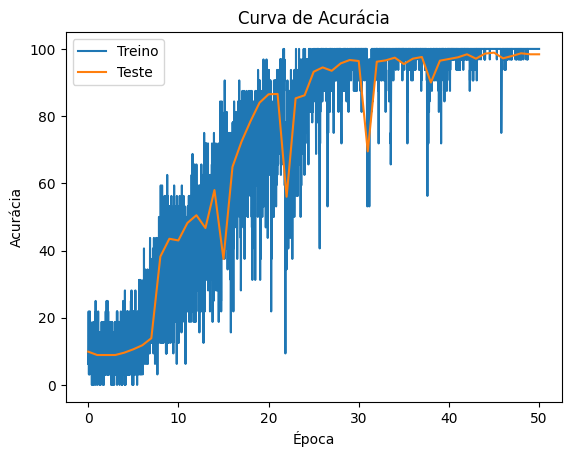

In [ ]:
x_axis = np.linspace(0, epochs, len(train_acc_hist))
plt.plot(x_axis, train_acc_hist, label='Treino')
plt.plot(test_acc_hist, label='Teste')
plt.title('Curva de Acurácia')  # Adiciona título
plt.xlabel('Época')  # Rótulo do eixo x
plt.ylabel('Acurácia')
plt.legend()

# IMPLEMENTAÇÕES EXTRA VGG E RESNET

Para facilitar os testes, decidimos implementar uma **VGG customizada** onde a quantidade de blocos é parametrizável, passando essa lista como parâmetro e gerando a classe `VGG_custom`. Durante os testes, observamos que ao aumentar o número de camadas da VGG, o modelo não conseguia treinar adequadamente. A principal hipótese para esse fenômeno é o problema de **vanish gradient ou exploding gradient**, que pode ser mitigado com uma inicialização correta dos pesos da rede, seguindo a lógica de **inicialização proposta** pelo understanding deep learning.

Além disso, ao tentar reproduzir o paper da **ResNet**, instanciamos duas redes VGG:
- Uma com `x` camadas
- Outra com `y` camadas, sendo `y` maior que `x`.

Observamos que a rede com menos camadas treinava melhor. Contudo, ao implementar a rede maior usando a arquitetura ResNet, notamos que isso se inverteu. No entanto, suspeitamos que isso poderia ser devido à camada de **batch normalization** ao invés das ligações residuais, a qual pode substituir a necessidade de uma inicialização específica dos pesos.

Por isso, decidimos implementar a VGG com **batch normalization** e construir uma ResNet baseada nessa arquitetura modificada, para que a comparação entre as redes seja o mais justa possível.


In [14]:
'''
As implementações da VGG e da RESnet feitas anteriormente não são
parametrizáveis, para contribuir nos testes, decidimos refazer esses dois
modelos de modo que seja possível parametrizar na vgg a quantidade de blocos e
na RESNET a profundidade da rede, optamos também por fazer uma versão da vgg com
batch normalization, para que assim, possamos obter comparações justas entre
vgg e resnet, além disso, as redes abaixo possuem mesma arquitetura, a
diferença é que a vgg_bn possui uma camada de batch_norm entre as convs e a
resnet_custom possui ligações residuais entre as camadas
'''

class VGG_custom(nn.Module):
    '''
    A rede recebe como parâmetro uma lista, o tamanho da lista é a
    quantidade de blocos vgg que possuimos, e em cada posição recebemos a
    quantidade de convs naquele bloco.
    Por exemplo, para replicar a rede feita no exercício acima, basta
    instanciar essa rede com parâmetro = [2, 2, 3]
    '''
    def __init__(self, blocos):
        super().__init__()

        layers = []
        in_channels = 1
        out_channels = 64

        '''
        Para cada bloco e cada conv presente no bloco a rede recebe a própria
        conv e a camada relu de ativação, além disso, a cada bloco, o número de
        canais de saída é duplicado, mantendo a estrutura da rede vgg, como
        também a rede recebe uma camada de maxpool que reduz a dimensão do x
        pela metade, por possuir stride 2 e kernel 2
        '''
        for i, num_conv_layers in enumerate(blocos):
            for _ in range(num_conv_layers):
                layers.append(nn.Conv1d(in_channels,
                                        out_channels,
                                        kernel_size=3,
                                        padding=1))

                layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels
            layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            out_channels *= 2

        self.conv_layers = nn.Sequential(*layers)

        self._to_linear = self._calculate_conv_output_size(40)

        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def _calculate_conv_output_size(self, input_size):
        x = torch.zeros(1, 1, input_size)
        x = self.conv_layers(x)
        return x.numel() // x.size(0)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


class VGG_bn(nn.Module):
    '''
    Implementando a mesma vgg acima, mas adicionando camadas de
    batch_normaliation, repare que o codigo é literalmente o mesmo com a adição
    da batch_norm entre cada conv e relu
    '''
    def __init__(self, blocos):
        super().__init__()

        layers = []
        in_channels = 1
        out_channels = 64

        for i, num_conv_layers in enumerate(blocos):
            for _ in range(num_conv_layers):
                layers.append(nn.Conv1d(in_channels,
                                        out_channels,
                                        kernel_size=3,
                                        padding=1))

                layers.append(nn.BatchNorm1d(out_channels)) # LINHA ADICIONADA
                layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels
            layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            out_channels *= 2

        self.conv_layers = nn.Sequential(*layers)

        self._to_linear = self._calculate_conv_output_size(40)

        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def _calculate_conv_output_size(self, input_size):
        x = torch.zeros(1, 1, input_size)
        x = self.conv_layers(x)
        return x.numel() // x.size(0)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x


class ResNet_custom(nn.Module):
    '''
    Vale ressaltar que essa rede é praticamente identica a VGG_bn, que é a vgg
    com batch_norm, contudo, adiciona conexões residuais entre camadas. Um dos
    desafios da implementação dessa rede foi o de trabalhar com a dimensão das
    comadas residuais.
    '''
    def __init__(self, blocos):
        super(ResNet_custom, self).__init__()

        self.layers = []
        in_channels = 1  # Iniciando com 1 canal de entrada
        out_channels = 64  # Primeira camada expansível para 64 canais

        for num_conv_layers in blocos:
            block_layers = []
            for _ in range(num_conv_layers):
                block_layers.append(nn.Conv1d(in_channels,
                                              out_channels,
                                              kernel_size=3,
                                              padding=1))
                block_layers.append(nn.BatchNorm1d(out_channels))
                block_layers.append(nn.ReLU(inplace=True))
                in_channels = out_channels

            # Definindo a camada de adaptação se necessário
            if in_channels != out_channels:
                # Atualizar o número de in_channels para combinar com os
                #out_channels após o bloco
                residual_layer = nn.Sequential(
                    nn.Conv1d(in_channels,
                              out_channels,
                              kernel_size=1,
                              stride=2),
                    nn.BatchNorm1d(out_channels)
                )
            else:
                residual_layer = nn.Identity()

            block_layers.append(residual_layer)
            # Adicionar as camadas do bloco à lista geral de camadas
            self.layers.extend(block_layers)
            self.layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
            out_channels *= 2  # Dobrar os out_channels para o próximo bloco

        self.conv_layers = nn.Sequential(*self.layers)
        self._to_linear = self._calculate_conv_output_size(40)
        self.fc_layers = nn.Sequential(
            nn.Linear(self._to_linear, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 10)
        )

    def _calculate_conv_output_size(self, input_size):
        x = torch.zeros(1, 1, input_size)
        x = self.conv_layers(x)
        return x.numel() // x.size(0)

    def forward(self, x):
        x = x.view(x.size(0), 1, 40)
        for layer in self.conv_layers:
            if isinstance(layer, nn.Sequential) and len(layer) == 2:
                x = layer(x) + x  # Aplicar a camada e somar com o residual
            else:
                x = layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# COMPARAÇÕES

In [ ]:
'''Essa função vai ser utilizada para comparaões entre modelos'''

def plot_metrics(results):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))  # 2 linhas, 2 colunas

    # Configuração dos subplots
    axs[0, 0].set_title('Perda de Treino')
    axs[0, 1].set_title('Acurácia de Treino')
    axs[1, 0].set_title('Perda de Teste')
    axs[1, 1].set_title('Acurácia de Teste')

    # Ajuste para todos os eixos
    for i in range(2):
        for j in range(2):
            axs[i, j].set_xlabel('Épocas')
            axs[i, j].grid(True)

    axs[0, 0].set_ylabel('Perda')
    axs[0, 1].set_ylabel('Acurácia')
    axs[1, 0].set_ylabel('Perda')
    axs[1, 1].set_ylabel('Acurácia')

    # Plotando os dados
    for name, data in results.items():
        axs[0, 0].plot(data[0], label=f"{name} - Treino")
        axs[0, 1].plot(data[2], label=f"{name} - Treino")
        axs[1, 0].plot(data[1], label=f"{name} - Teste")
        axs[1, 1].plot(data[3], label=f"{name} - Teste")

    # Adicionando legendas
    for i in range(2):
        for j in range(2):
            axs[i, j].legend()

    plt.tight_layout()
    plt.show()

## LINEAR VS MLP

In [ ]:
epochs = 50

In [ ]:
modelos = [LinearNet(), MLPNet()]

results = {
    'LinearNet': [],
    'MLPNet': []
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando LinearNet


100%|██████████| 50/50 [00:11<00:00,  4.18it/s]


Treinando MLPNet


100%|██████████| 50/50 [00:17<00:00,  2.84it/s]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: LinearNet
LOSS FINAL TESTE: 1.671779716014862
ACC FINAL TESTE: 32.0

Modelo: MLPNet
LOSS FINAL TESTE: 1.4891818940639496
ACC FINAL TESTE: 65.4



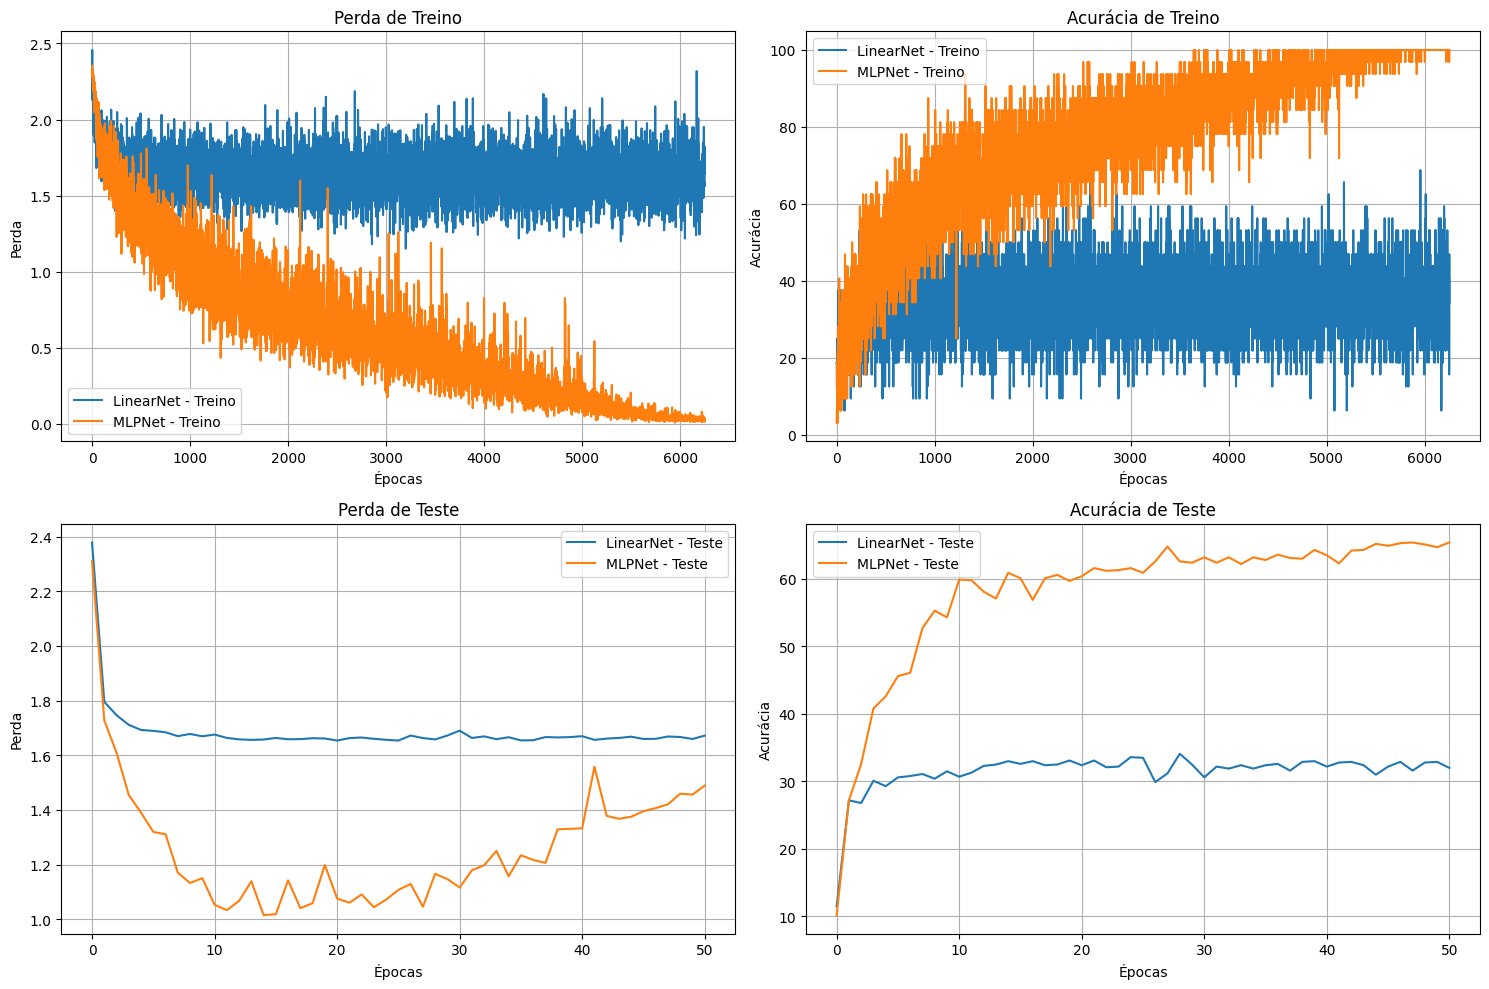

In [ ]:
plot_metrics(results)

Sabemos que uma mlp é um aproximador universal de funções, e que quanto maior a rede maior o conjunto de funções atingíveis, com isso, ao implementar uma linear, que é uma simples reta/plano, o esperado é que se performe pior que uma mlp com algo perto de 20 mil parâmetros e não-linearidade, isso por que, a mlp pode aproximar um conjunto muito maior de funções, inclusive a reta/plano do modelo linear. O fato descrito foi o observado nos resultados acima, onde temos uma mlp com menor loss de treino e teste, como também um melhor valor de acurácia.

## MLP VS LENET

In [ ]:
modelos = [MLPNet(), LeNet()]

results = {
    'MLPNet': [],
    'LeNet' : []
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando MLPNet


100%|██████████| 50/50 [00:16<00:00,  2.99it/s]


Treinando LeNet


100%|██████████| 50/50 [00:22<00:00,  2.21it/s]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: MLPNet
LOSS FINAL TESTE: 1.5308322072029115
ACC FINAL TESTE: 63.7

Modelo: LeNet
LOSS FINAL TESTE: 0.3407220780849457
ACC FINAL TESTE: 93.4



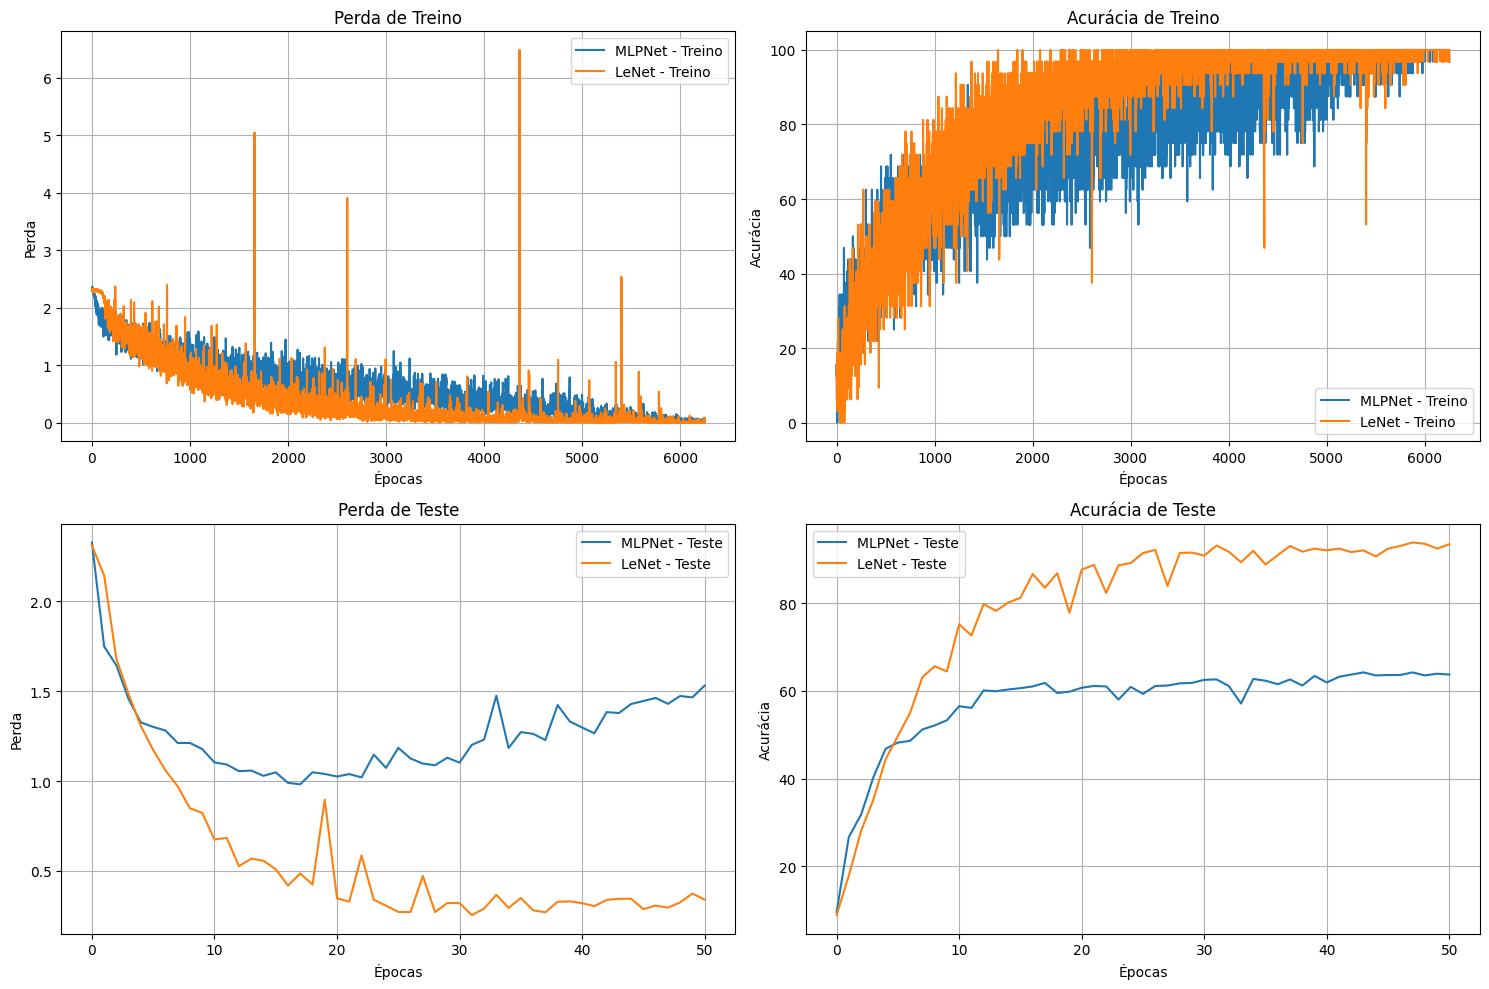

In [ ]:
plot_metrics(results)

A afirmação da comparação entre a **LinearNet** e a **MLPNet** é forte, e faz surgir a seguinte dúvida: já que quanto mais parâmetros, maior o campo de funções atingíveis, e não conhecemos nossa função alvo, uma rede com mais parâmetros deveria performar melhor que uma rede que possui menos parâmetros, certo? Contudo, vimos que  resultado da **LeNet** se mostrou melhor que a **MLP** duas vezes maior, fato que se deve à inserção das camadas convolucionais.

Isso não significa que uma **MLP** não seja capaz de aproximar a função que descreve nosso evento sobre os dados, tanto que ela fez isso muito bem para os dados de treino, mas sim que isso pode ser muito difícil, devido à maneira como o problema em si existe ou como foi modelado. Para nossos dados (**MNIST-1D**) sabemos que, independente da posição do dígito na imagem, a resposta continua igual; sabemos que se deslocado um único pixel à direita, isso não deveria fazer nenhuma diferença dentro do problema.

Mas quando tratamos de **MLP** (totalmente conectada), a relação entre os pesos e a entrada é de um para um, ou seja, uma imagem com um único pixel deslocada representa um outro problema para a rede, algo que não acontece com a convolucional, que podemos enxergar como um único (ou vários) neurônio(s) deslizando sobre a entrada, assim eliminando o problema da localidade.

Mas novamente, não é impossível que a **MLP** aprenda a função que resolve o problema, mas é muito mais custoso, pois talvez precisemos de dados quase infinitos para cobrir todas as possibilidades da forma que o problema foi modelado, talvez precisemos de muitas épocas para permitir esse aprendizado. Quando na prática, modelar o problema de outra forma pode torná-lo resolvível de maneira muito mais simples, onde no fim de tudo, utilizamos a ideia da **MLP** (aproximador universal) e inserimos nosso conhecimento na modelagem, conhecimento esse, nesse caso, de que a localidade não importa, por exemplo, criando camadas convolucionais.

Na prática, ainda temos um aproximador de funções, mas agora, a função a se aprender se torna muito mais simples, por exeplo, pela simples diminuição do conjunto entrada de entrada e saída através da convolução, visto que na mlp tinhamos uma conexão um para um.


## LENET VS VGG

In [ ]:
modelos = [LeNet(), VGGNet()]

results = {
    'LeNet' : [],
    'VGGNet' : []
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando LeNet


100%|██████████| 50/50 [00:22<00:00,  2.24it/s]


Treinando VGGNet


100%|██████████| 50/50 [01:58<00:00,  2.36s/it]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: LeNet
LOSS FINAL TESTE: 0.36929501295089723
ACC FINAL TESTE: 92.7

Modelo: VGGNet
LOSS FINAL TESTE: 0.07302599865943193
ACC FINAL TESTE: 98.4



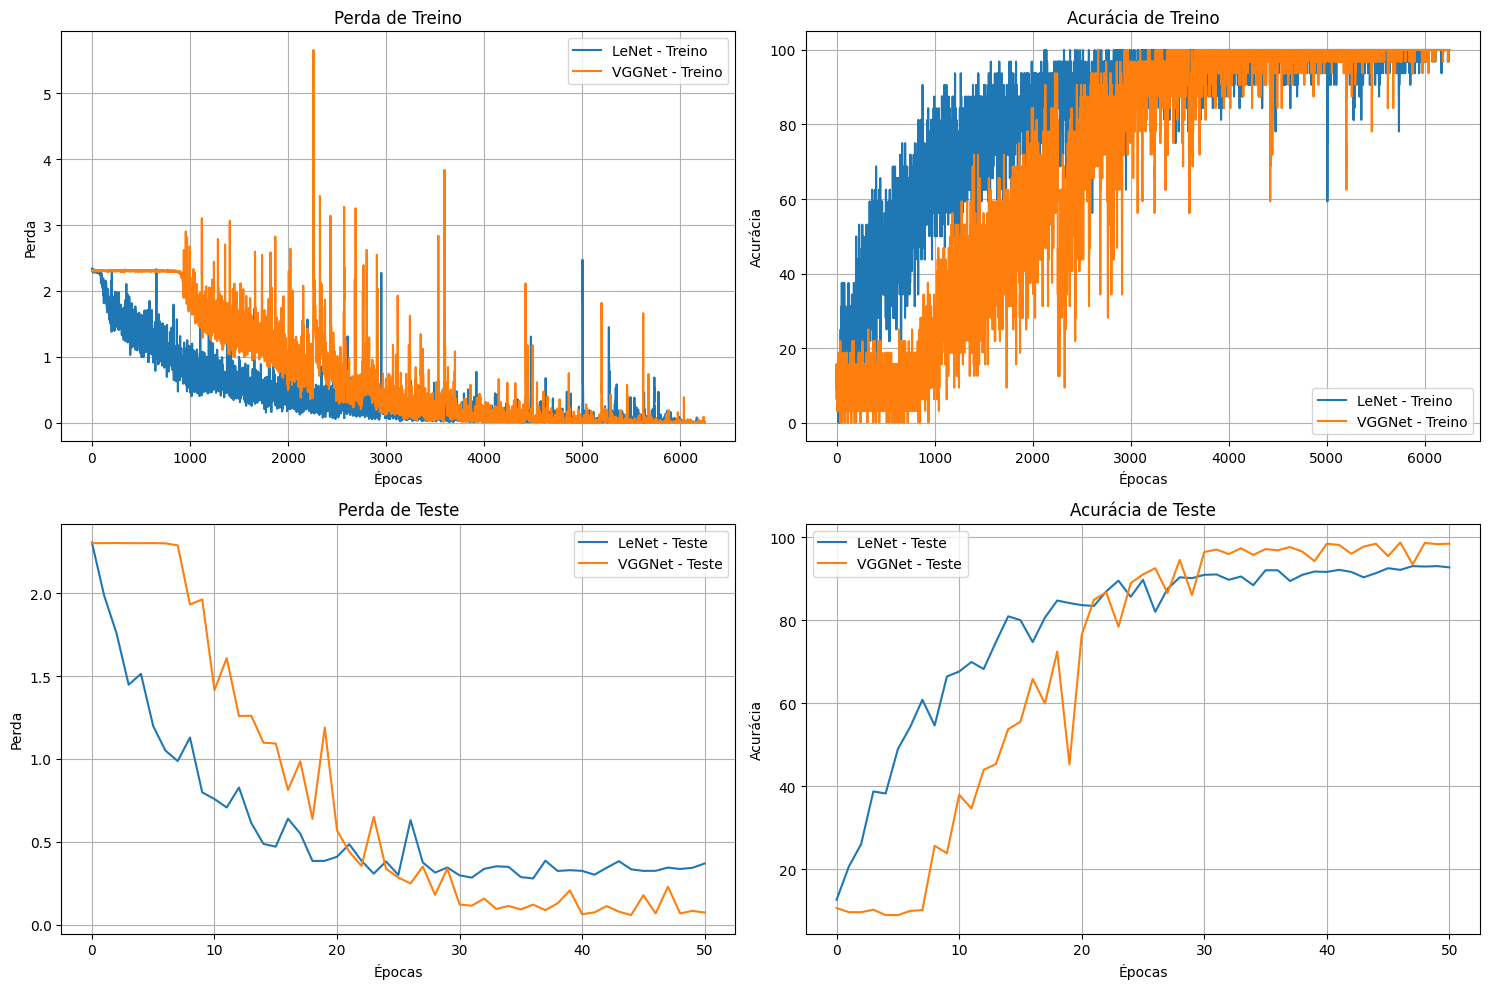

In [ ]:
plot_metrics(results)

A ideia por trás da **VGG** é criar uma rede mais profunda que a **LeNet**, organizada em blocos que aumentam a quantidade de filtros convolucionais enquanto reduzem pela metade o tamanho das entradas a cada bloco. Um ponto interessante a ser destacado é a relação entre a quantidade de parâmetros e a capacidade da rede de abranger um espaço mais amplo de funções: a **VGG** testada possui mais de 22 milhões de parâmetros. Para um problema relativamente simples como o **MNIST-1D**, tanto a **LeNet** quanto a **VGG** alcançam resultados próximos, o que nos leva a ponderar sobre o trade-off entre o aumento no número de parâmetros e os benefícios resultantes, mas ainda assim, podem existir problemas em que aumentar os parâmetros desse modo faça mais sentido. Além disso, observamos que o treinamento da **VGG** é um pouco mais desafiador, pois leva mais tempo para alcançar os níveis de desempenho da **LeNet** e, eventualmente, superá-los. Dada a capacidade de parametrização das **VGGs**, com a adição de mais blocos, dedicaremos uma seção especial a elas.


## VGG E BLOCOS

In [ ]:
modelos = [VGG_custom([2, 2]), VGG_custom([2, 2, 2]),
           VGG_custom([3, 3, 3]), VGG_custom([5, 5, 5])]

results = {
    'VGG 4 camadas' : [],
    'VGG 6 camadas' : [],
    'VGG 9 camadas' : [],
    'VGG 15 camadas' : [],
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando VGG 4 camadas


100%|██████████| 50/50 [01:46<00:00,  2.14s/it]


Treinando VGG 6 camadas


100%|██████████| 50/50 [02:00<00:00,  2.41s/it]


Treinando VGG 9 camadas


100%|██████████| 50/50 [02:12<00:00,  2.64s/it]


Treinando VGG 15 camadas


100%|██████████| 50/50 [02:23<00:00,  2.87s/it]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: VGG 4 camadas
LOSS FINAL TESTE: 0.09520924652460963
ACC FINAL TESTE: 97.7

Modelo: VGG 6 camadas
LOSS FINAL TESTE: 0.07554597314447165
ACC FINAL TESTE: 98.2

Modelo: VGG 9 camadas
LOSS FINAL TESTE: 1.5722565412521363
ACC FINAL TESTE: 32.1

Modelo: VGG 15 camadas
LOSS FINAL TESTE: 2.3035531282424926
ACC FINAL TESTE: 8.9



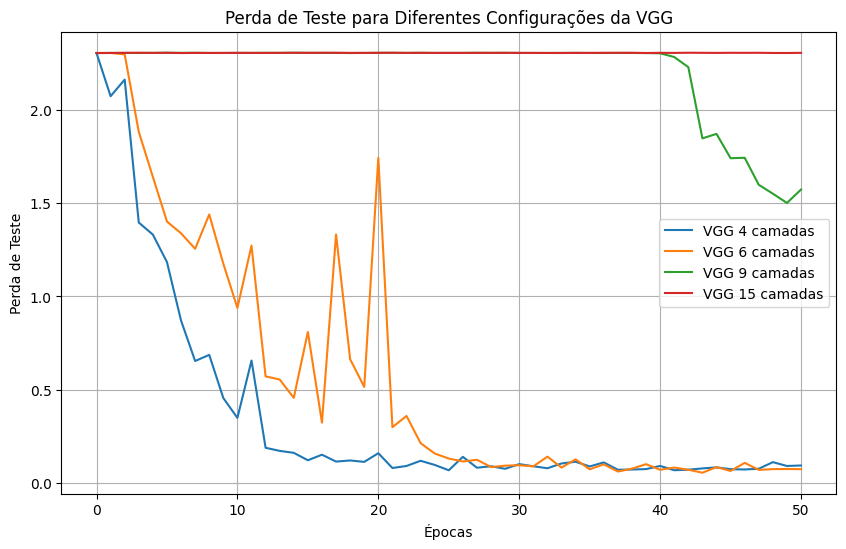

In [ ]:
plt.figure(figsize=(10, 6))

for name, data in results.items():
    test_loss_hist = data[1]
    plt.plot(test_loss_hist, label=name)

plt.title('Perda de Teste para Diferentes Configurações da VGG')
plt.xlabel('Épocas')
plt.ylabel('Perda de Teste')
plt.legend()
plt.grid(True)

plt.show()

Assim é possível ver que rapidamente, ao aumentar a profundidade da rede começamos a ter problemas com o treinamento, onde a hipótese é de que isso ocorre devido ao problema de **vanish gradient ou exploding gradient**, onde buscaremos mitigar isso usando camadas que batch_norm, mas poderia ser feito realizando uma inicialização adequada da rede, conforme descreve o livro understanding deep learning. Assim, vamos realizar novamente os testes para redes maiores, mas com camdas de batch_norm entre as convs

In [ ]:
modelos = [VGG_bn([2, 2, 2]), VGG_bn([3, 3, 3]),
           VGG_bn([5, 5, 5]), VGG_bn([8, 8, 8])]

results = {
    'VGG 6 camadas BN' : [],
    'VGG 9 camadas BN' : [],
    'VGG 15 camadas BN' : [],
    'VGG 24 camadas BN' : [],
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando VGG 6 camadas BN


100%|██████████| 50/50 [02:09<00:00,  2.60s/it]


Treinando VGG 9 camadas BN


100%|██████████| 50/50 [02:16<00:00,  2.73s/it]


Treinando VGG 15 camadas BN


100%|██████████| 50/50 [02:53<00:00,  3.47s/it]


Treinando VGG 24 camadas BN


100%|██████████| 50/50 [03:23<00:00,  4.08s/it]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: VGG 6 camadas BN
LOSS FINAL TESTE: 0.044524278677999976
ACC FINAL TESTE: 98.8

Modelo: VGG 9 camadas BN
LOSS FINAL TESTE: 0.026772522929240948
ACC FINAL TESTE: 98.8

Modelo: VGG 15 camadas BN
LOSS FINAL TESTE: 0.052831154270097616
ACC FINAL TESTE: 98.3

Modelo: VGG 24 camadas BN
LOSS FINAL TESTE: 0.048192510823719205
ACC FINAL TESTE: 99.0



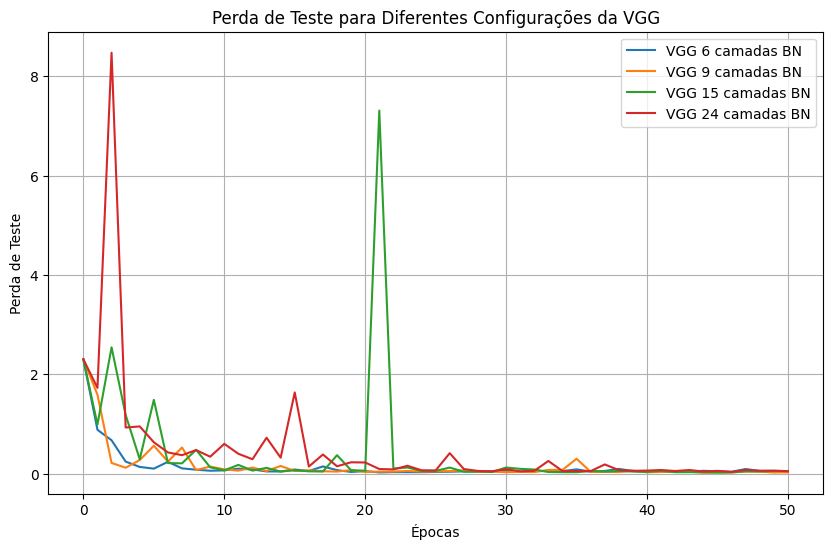

In [ ]:
plt.figure(figsize=(10, 6))

for name, data in results.items():
    test_loss_hist = data[1]
    plt.plot(test_loss_hist, label=name)

plt.title('Perda de Teste para Diferentes Configurações da VGG')
plt.xlabel('Épocas')
plt.ylabel('Perda de Teste')
plt.legend()
plt.grid(True)

plt.show()

Assim, vemos que somente adicionando camadas de batch_norm, foi possível treinar redes com mais camadas, mesmo com princípios falhos do artigo, busca-se resolver as diferenças de magnitude entre camadas, por exemplo, se uma camada tiver ativações variáveis que são 100 vezes maiores que as de outra camada, isso pode necessitar de ajustes compensatórios nas taxas de aprendizado, assim, provavelmente dificultando o aprendizado das redes implementadas anteriormente.

## VGG VS RESNET

In [ ]:
modelos = [VGGNet(), ResNet()]

results = {
    'VGGNet' : [],
    'ResNet' : []
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando VGGNet


100%|██████████| 50/50 [02:10<00:00,  2.60s/it]


Treinando ResNet


100%|██████████| 50/50 [02:53<00:00,  3.47s/it]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: VGGNet
LOSS FINAL TESTE: 0.09214180521667004
ACC FINAL TESTE: 98.0

Modelo: ResNet
LOSS FINAL TESTE: 0.07560632734093815
ACC FINAL TESTE: 98.4



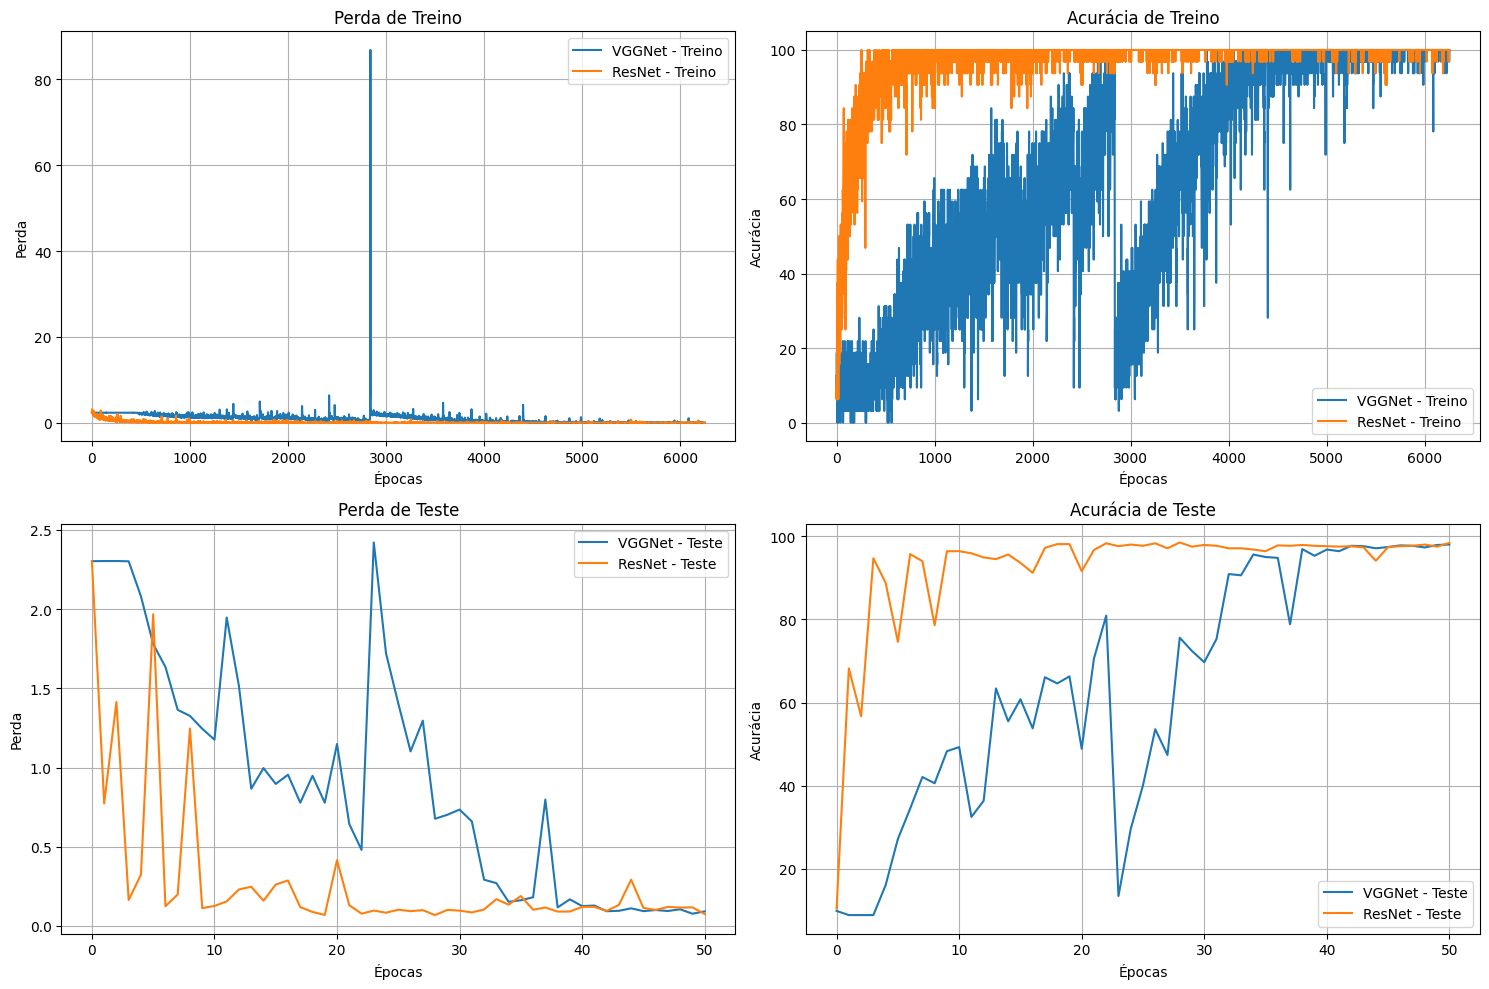

In [ ]:
plot_metrics(results)

É possível perceber que mesmo que o resultado tenha sido próximo, a ResNet converge muito mais rápido e apresenta um comportamento muito mais estável que o da vgg.
Vimos que a ResNet se saiu melhor, mesmo com uma arquitetura semelhante, mas como vimos anteriormente não é possível declarar que a principal razão disso são as ligações residuais, visto a importância das camadas de batch_norm já discutidas. Por isso, a a diferença entre a implementação da ResNet_Custom e VGG_bn fica somente nas ligações residuais, sendo assim mais justo o comparativo.

In [ ]:
modelos = [VGG_bn([4, 4, 4]), ResNet_custom([4, 4, 4])]

results = {
    'VGG 12 camadas BN' : [],
    'ResNet 12 camadas' : []
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando VGG 12 camadas BN


100%|██████████| 50/50 [02:32<00:00,  3.05s/it]


Treinando ResNet 12 camadas


100%|██████████| 50/50 [02:33<00:00,  3.08s/it]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: VGG 12 camadas BN
LOSS FINAL TESTE: 0.039598347636638206
ACC FINAL TESTE: 99.0

Modelo: ResNet 12 camadas
LOSS FINAL TESTE: 0.01976474117182079
ACC FINAL TESTE: 99.3



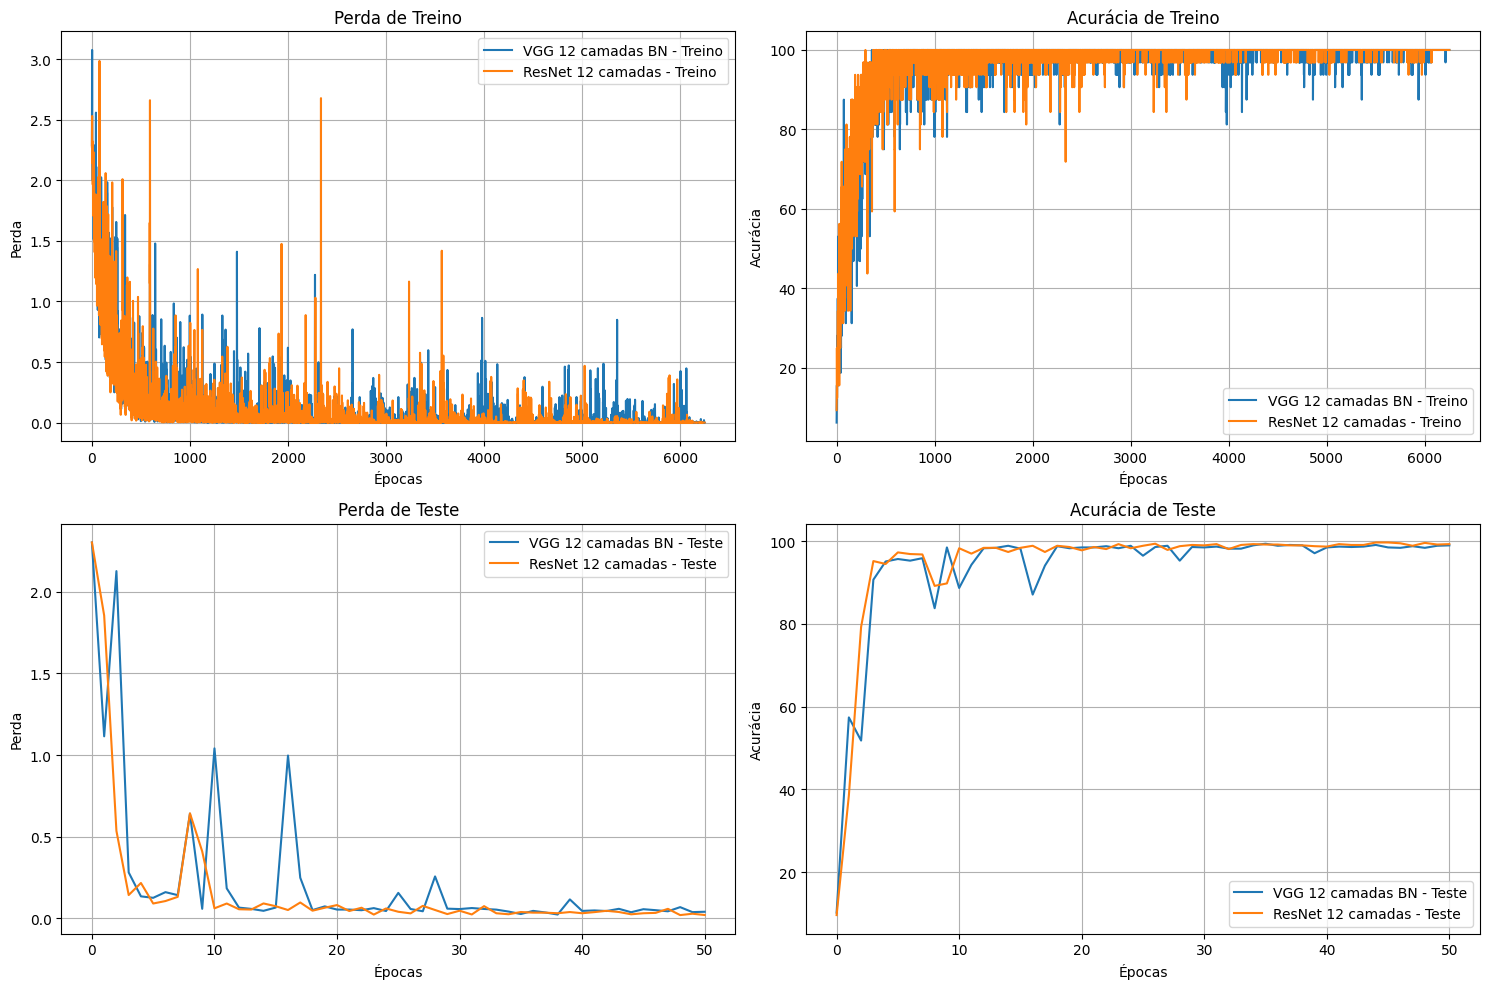

In [ ]:
plot_metrics(results)

Aqui vemos que existe uma diferença bem pequena, mas ainda é possível perceber que a resnet apresentou um comportamento pouco melhor que a vgg com mesmo número de camadas, esse comportamente pode ficar interessante se crescermos mais ainda a rede

In [ ]:
modelos = [VGG_bn([8, 8, 8, 8]), ResNet_custom([8, 8, 8, 8])]

results = {
    'VGG 32 camadas BN' : [],
    'ResNet 32 camadas' : []
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando VGG 32 camadas BN


100%|██████████| 50/50 [06:38<00:00,  7.97s/it]


Treinando ResNet 32 camadas


100%|██████████| 50/50 [06:02<00:00,  7.25s/it]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: VGG 32 camadas BN
LOSS FINAL TESTE: 0.6049891710281372
ACC FINAL TESTE: 87.7

Modelo: ResNet 32 camadas
LOSS FINAL TESTE: 0.15996463224291801
ACC FINAL TESTE: 95.4



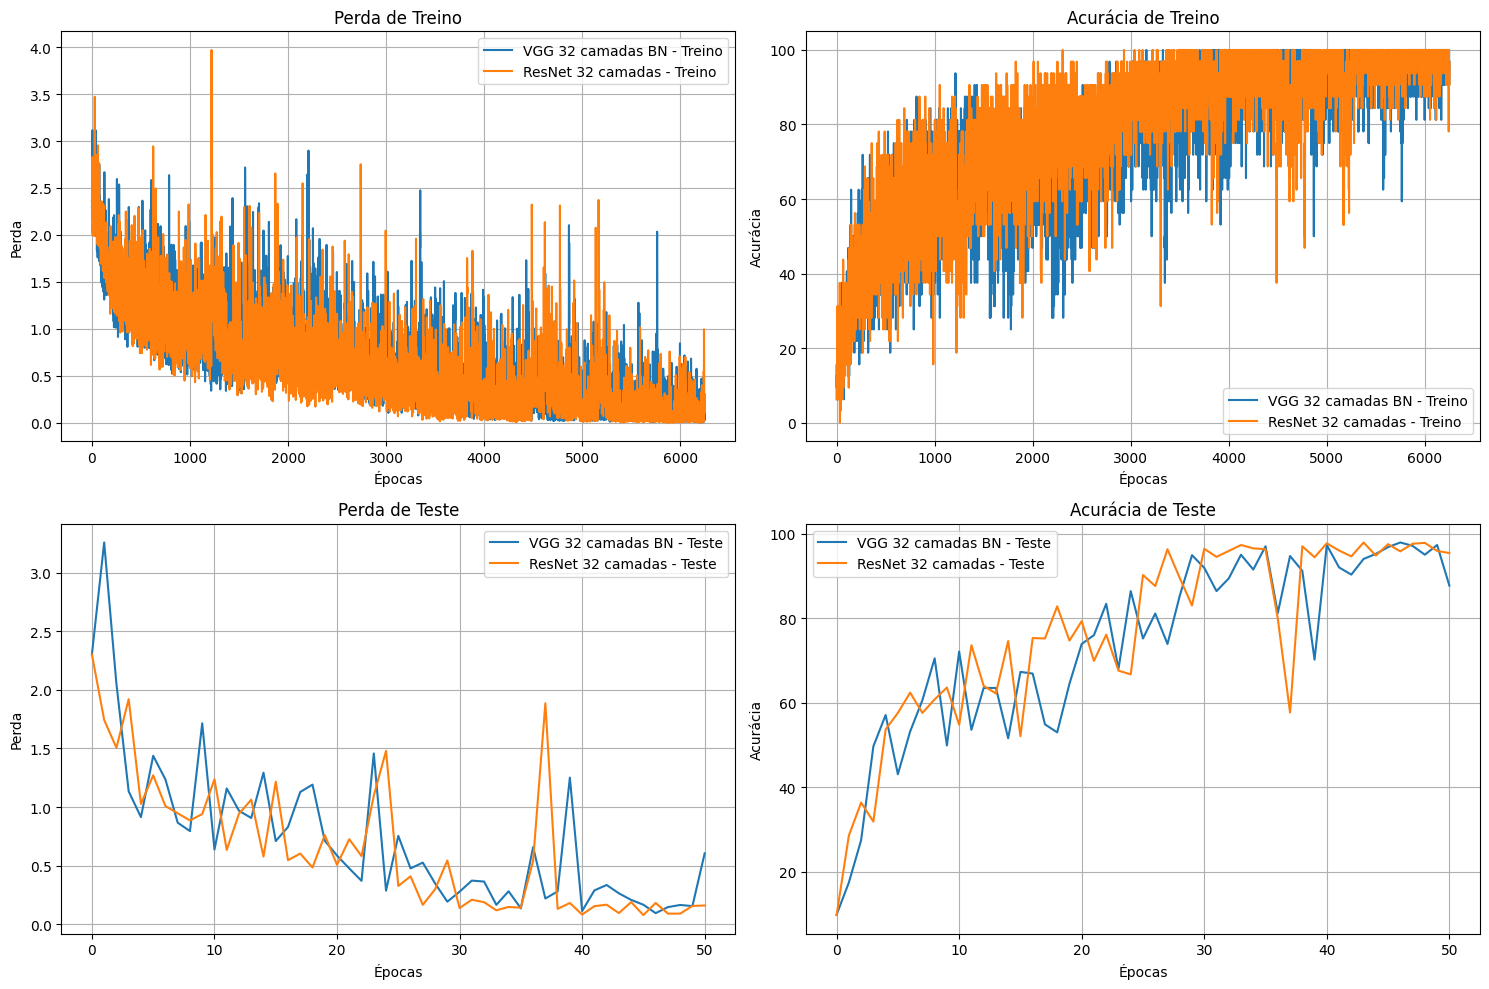

In [ ]:
plot_metrics(results)

## RNN, VIT e MLP

In [ ]:
modelos = [RecurrentNet(), ViTNet(), MLPNet()]

results = {
    'RecurrentNet' : [],
    'ViTNet' : [],
    'MLPNet' : [],
}

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando RecurrentNet


100%|██████████| 50/50 [00:19<00:00,  2.57it/s]


Treinando ViTNet


100%|██████████| 50/50 [00:29<00:00,  1.69it/s]


Treinando MLPNet


100%|██████████| 50/50 [00:16<00:00,  3.11it/s]


In [ ]:
for name, data in results.items():
    test_loss_hist = data[1]
    test_acc_hist = data[3]

    print(f"Modelo: {name}")
    print(f"LOSS FINAL TESTE: {test_loss_hist[-1]}")
    print(f"ACC FINAL TESTE: {test_acc_hist[-1]}")
    print()

Modelo: RecurrentNet
LOSS FINAL TESTE: 1.0269943952560425
ACC FINAL TESTE: 62.0

Modelo: ViTNet
LOSS FINAL TESTE: 1.1118741750717163
ACC FINAL TESTE: 66.1

Modelo: MLPNet
LOSS FINAL TESTE: 1.6405396699905395
ACC FINAL TESTE: 62.1



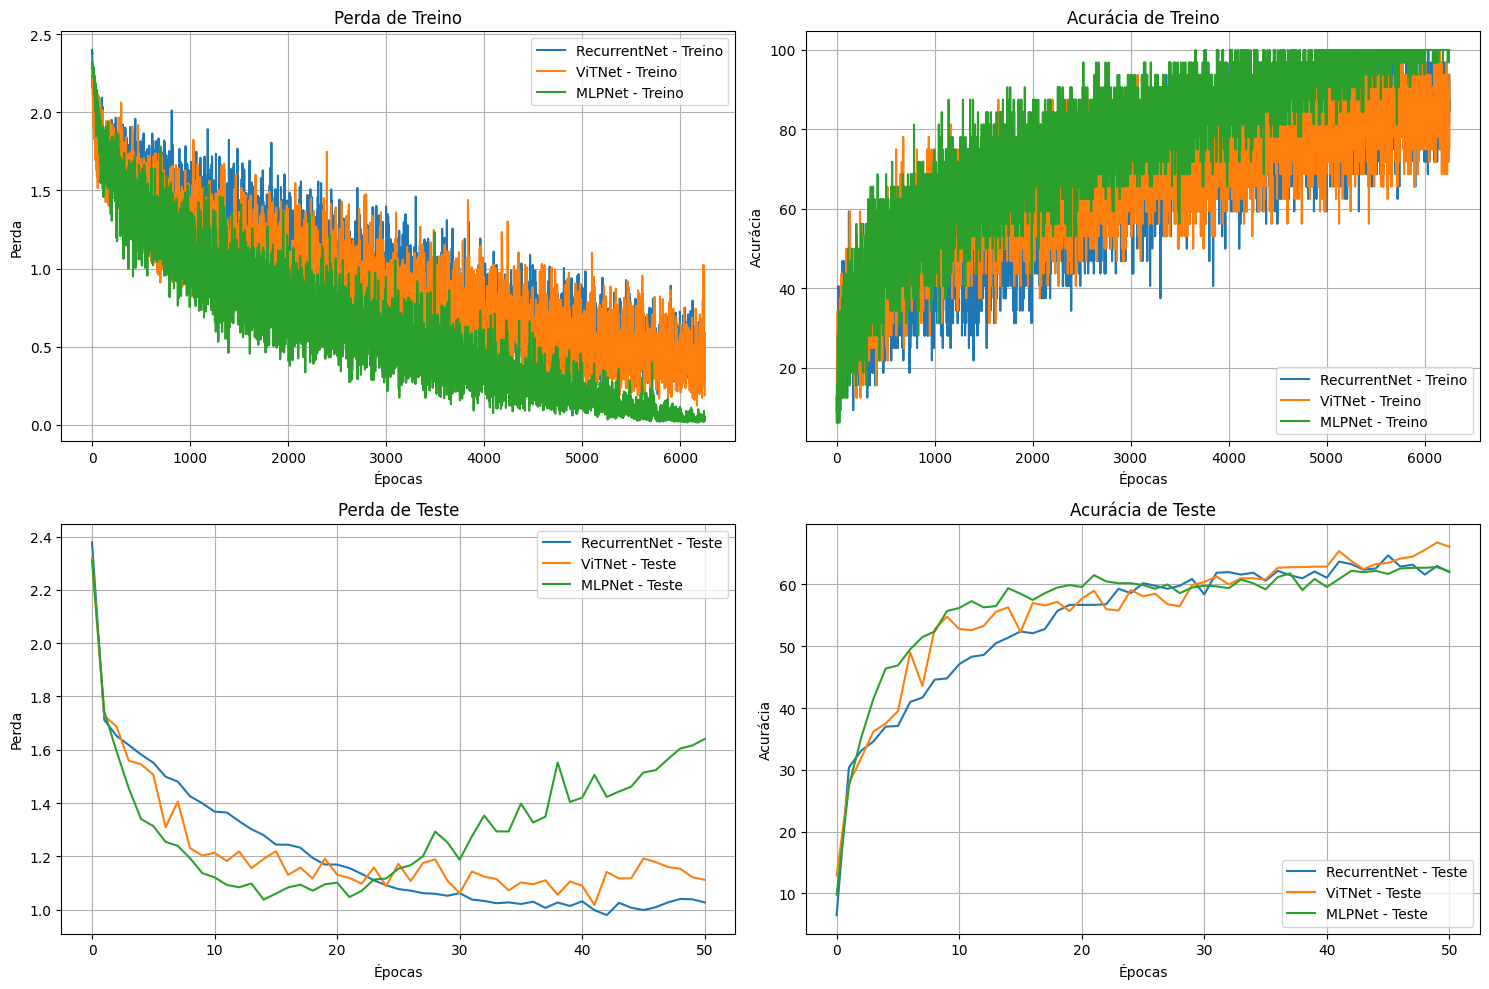

In [ ]:
plot_metrics(results)

### MLP (Multilayer Perceptron):
- Embora MLPs sejam aproximadores universais de funções, eles carecem da capacidade de modelar explicitamente a localidade e as hierarquias dos padrões visuais sem extensa pré-engenharia de características ou aumento da complexidade do modelo.

### RNN (Redes Recorrentes):
- As redes recorrentes são adequadas para capturar dependências sequenciais, mas podem não ser tão eficazes em distinguir padrões espaciais simplificados como os apresentados em MNIST 1D, onde a ordem sequencial fixa e a falta de dependências temporais complexas limitam sua eficácia.

### ViT (Vision Transformer):
- O ViT, embora poderoso em capturar interações globais via mecanismo de atenção, pode não superar as redes convolucionais em tarefas onde as características locais e a invariância espacial são cruciais. Além disso, os Transformers requerem grandes quantidades de dados e capacidade computacional para generalizar bem, o que pode não ser totalmente aproveitado no cenário do MNIST 1D.


## VISUALIZAÇÃO GERAL

In [ ]:
modelos = [RecurrentNet(), ViTNet(), MLPNet(),
           ResNet(), LeNet(), LinearNet(), VGGNet()]

results = {
    'RecurrentNet' : [],
    'ViTNet' : [],
    'MLPNet' : [],
    'ResNet' : [],
    'LeNet' : [],
    'Linear' : [],
    'VGG' : []
}
epochs = 40

for modelo, nome in zip(modelos, results.keys()):
    print(f"Treinando {nome}")
    model = modelo.to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-1)

    train_loss_hist = []
    train_acc_hist = []

    test_loss_0, test_acc_0 = test(test_dataloader, model, loss_fn)
    test_loss_hist = [test_loss_0]
    test_acc_hist = [test_acc_0]

    for t in trange(epochs):
        train_loss, train_acc = train(train_dataloader,
                                      model,
                                      loss_fn,
                                      optimizer)

        train_loss_hist.extend(train_loss)
        train_acc_hist.extend(train_acc)

        test_loss, test_acc = test(test_dataloader, model, loss_fn)
        test_loss_hist.append(test_loss)
        test_acc_hist.append(test_acc)

    train_loss_hist = np.array(train_loss_hist)
    test_loss_hist = np.array(test_loss_hist)
    train_acc_hist = np.array(train_acc_hist)
    test_acc_hist = np.array(test_acc_hist)

    results[nome] = [train_loss_hist, test_loss_hist,
                     train_acc_hist, test_acc_hist]


Treinando RecurrentNet


100%|██████████| 40/40 [00:15<00:00,  2.52it/s]


Treinando ViTNet


100%|██████████| 40/40 [00:25<00:00,  1.59it/s]


Treinando MLPNet


...

100%|██████████| 40/40 [00:16<00:00,  2.46it/s]


Treinando Linear


100%|██████████| 40/40 [00:09<00:00,  4.18it/s]


Treinando VGG


100%|██████████| 40/40 [01:34<00:00,  2.36s/it]


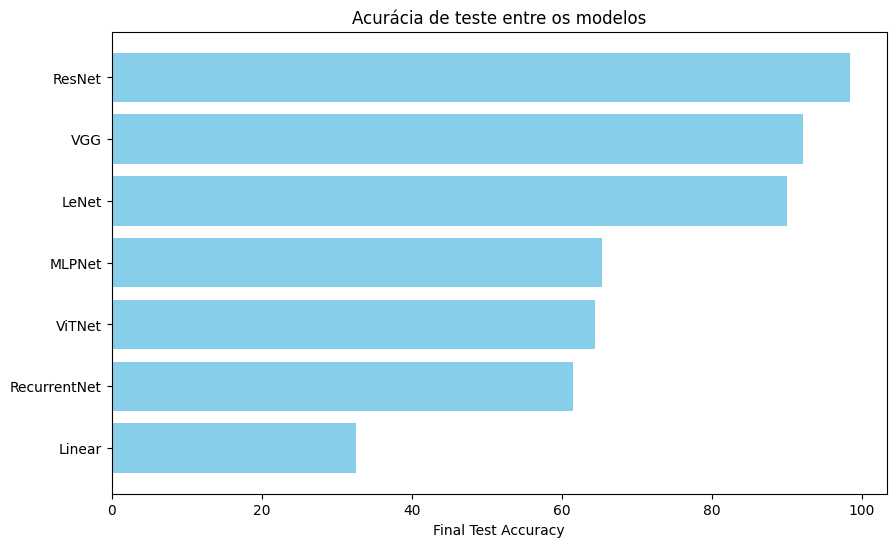

In [ ]:
def plot_final_test_accuracy(results):
    final_test_acc = {model_name: data[3][-1] for model_name, data in results.items()}

    sorted_models = sorted(final_test_acc.items(), key=lambda x: x[1], reverse=True)

    models, accuracies = zip(*sorted_models)

    plt.figure(figsize=(10, 6))
    plt.barh(models, accuracies, color='skyblue')
    plt.xlabel('Final Test Accuracy')
    plt.title('Acurácia de teste entre os modelos')
    plt.gca().invert_yaxis()
    plt.show()

plot_final_test_accuracy(results)


No experimento de classificação dos dígitos do MNIST 1D, a rede convolucional demonstrou desempenho significativamente superior em comparação às demais arquiteturas testadas, como MLP, redes recorrentes (RNN) e o Vision Transformer (ViT). Este resultado pode ser atribuído a várias características intrínsecas e vantagens das redes convolucionais em tarefas de processamento de imagem, mesmo quando adaptadas para um formato unidimensional.

### Eficiência das Convoluções:
- As redes convolucionais são especialmente projetadas para capturar padrões hierárquicos em dados visuais. Mesmo em uma versão unidimensional, as convoluções são capazes de extrair características locais relevantes ao longo da sequência de entrada. Isso permite que a rede construa uma representação eficaz e discriminativa dos dígitos, levando a uma melhor classificação.

### Localidade e Invariância à Translação:
- Uma das principais forças das convoluções é sua capacidade de capturar padrões locais que são invariantes à translação. No contexto de dígitos, isso significa que pequenas variações na posição ou alinhamento dos dígitos não afetam a capacidade de reconhecimento da rede, uma vantagem que modelos como MLP e RNN podem não explorar tão eficientemente.

### Redução Dimensional Progressiva:
- Através de camadas de pooling, as redes convolucionais progressivamente reduzem a dimensão dos dados, concentrando-se em características cada vez mais abstratas. Esta abordagem hierárquica é particularmente útil em tarefas de classificação onde a identificação de padrões em diferentes escalas pode ser crucial para o sucesso.